# 04 · The Heat Kernel Signature: diffusion as a local probe

**SpectralBrain tutorial series — notebook 4 of 10.** (Previous: ShapeDNA.)

ShapeDNA gave one fingerprint for a whole structure. To find out *where* shapes
differ we need a descriptor at **every vertex**. The **Heat Kernel Signature**
(HKS; Sun, Ovsjanikov & Guibas 2009) does exactly that, by watching how heat
diffuses away from each point across many time scales.

### Learning objectives
1. Define the HKS from the heat equation and the LBO spectrum.
2. See how scale ($t$) interpolates from local curvature to global shape.
3. Render HKS on the hippocampus and relate small-$t$ HKS to curvature.
4. Make it scale-invariant with **SI-HKS** and prove the invariance.


## 1. Heat flow and the heat kernel

Drop a unit of heat at a point $x$ and let it diffuse over the surface according
to the heat equation $\partial_t u = \Delta u$. The amount of heat remaining at
$x$ after time $t$ — the **heat kernel** evaluated on the diagonal — has a clean
spectral form:

$$\mathrm{HKS}(x, t) \;=\; k_t(x, x) \;=\; \sum_{k\ge 0} e^{-\lambda_k t}\,\varphi_k(x)^2 .$$

Read it as a recipe: each eigenfunction contributes its squared value, damped by
$e^{-\lambda_k t}$. The time $t$ is a **scale knob**:

- **small $t$** — only the highest frequencies have not yet decayed, so HKS senses
  the *immediate neighbourhood*: curvature and fine geometry.
- **large $t$** — only the lowest frequencies survive, so HKS reflects the point's
  place in the *global* shape.

Because it is built from $\lambda_k$ and $\varphi_k$, HKS inherits the LBO's
isometry invariance: it is intrinsic and pose-free, just like ShapeDNA, but
resolved per vertex.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
import spectralbrain as sb
from _tutorial_utils import data_path

v, f = sb.load_gifti_surface(
    data_path("hippunfold", "sub03", "hemi-L_space-T1w_den-8k_label-hipp_midthickness.surf.gii"))
hipp = sb.BrainMesh(v, f)
dec = hipp.decompose(k=200)          # HKS wants more modes than ShapeDNA

# Principled time scales from the spectrum: t in [4 ln10 / λ_max , 4 ln10 / λ_1].
lam = dec.eigenvalues
t_min = 4 * np.log(10) / lam[-1]
t_max = 4 * np.log(10) / lam[1]
t_grid = np.logspace(np.log10(t_min), np.log10(t_max), 100)
hks = np.asarray(sb.compute_hks(dec, t_values=t_grid))
print(f"HKS matrix: {hks.shape}  (vertices x time-scales)")
print(f"time range: {t_min:.3g} ... {t_max:.3g}")

[06/09/26 02:00:22] INFO     Laplacian (cotangent): N=8192, nnz=56578

HKS matrix: (8192, 100)  (vertices x time-scales)
time range: 3.54 ... 1.58e+03


## 2. One signature, many scales

For a handful of vertices, plot HKS as a function of $t$. Every curve is that
point's multi-scale identity card. Points in geometrically distinct locations
(a tip vs a flat flank) trace different curves; the spread across vertices is
largest at small $t$ (local detail) and collapses at large $t$ (everyone shares
the same global shape).

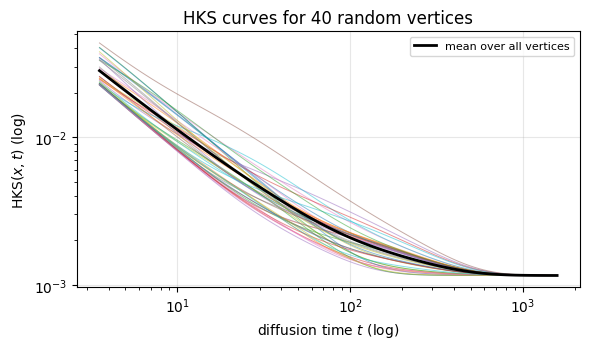

In [2]:
rng = np.random.default_rng(0)
sample = rng.choice(hipp.n_vertices, 40, replace=False)
fig, ax = plt.subplots(figsize=(6, 3.6))
for idx in sample:
    ax.plot(t_grid, hks[idx], lw=0.7, alpha=0.5)
ax.plot(t_grid, hks.mean(0), "k-", lw=2, label="mean over all vertices")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("diffusion time $t$ (log)"); ax.set_ylabel("HKS$(x,t)$ (log)")
ax.set_title("HKS curves for 40 random vertices"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. The spatial pattern changes with scale

Now fix three scales — small, medium, large — and paint HKS across the surface.
Watch the pattern reorganise: fine, curvature-driven structure at small $t$
broadens into smooth, head-to-tail organisation at large $t$.

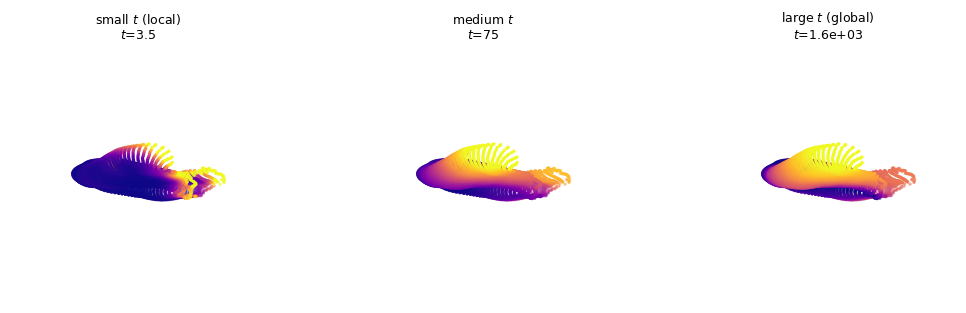

In [3]:
t3 = np.logspace(np.log10(t_min), np.log10(t_max), 3)
hks3 = np.asarray(sb.compute_hks(dec, t_values=t3))

V = hipp.vertices
fig = plt.figure(figsize=(10.5, 3.2))
for i, (t, lab) in enumerate(zip(t3, ["small $t$ (local)", "medium $t$", "large $t$ (global)"])):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    s = hks3[:, i]
    ax.scatter(V[:, 0], V[:, 1], V[:, 2], c=s, cmap="plasma", s=2,
               vmin=np.percentile(s, 2), vmax=np.percentile(s, 98))
    ax.set_title(f"{lab}\n$t$={t:.2g}", fontsize=9); ax.set_axis_off(); ax.view_init(20, -70)
plt.tight_layout(); plt.show()

The same medium-scale HKS, rendered with the six-view tool — the kind of figure
that goes into a paper.

2026-06-09 02:00:28.159 (   0.510s) [    7F8673792080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


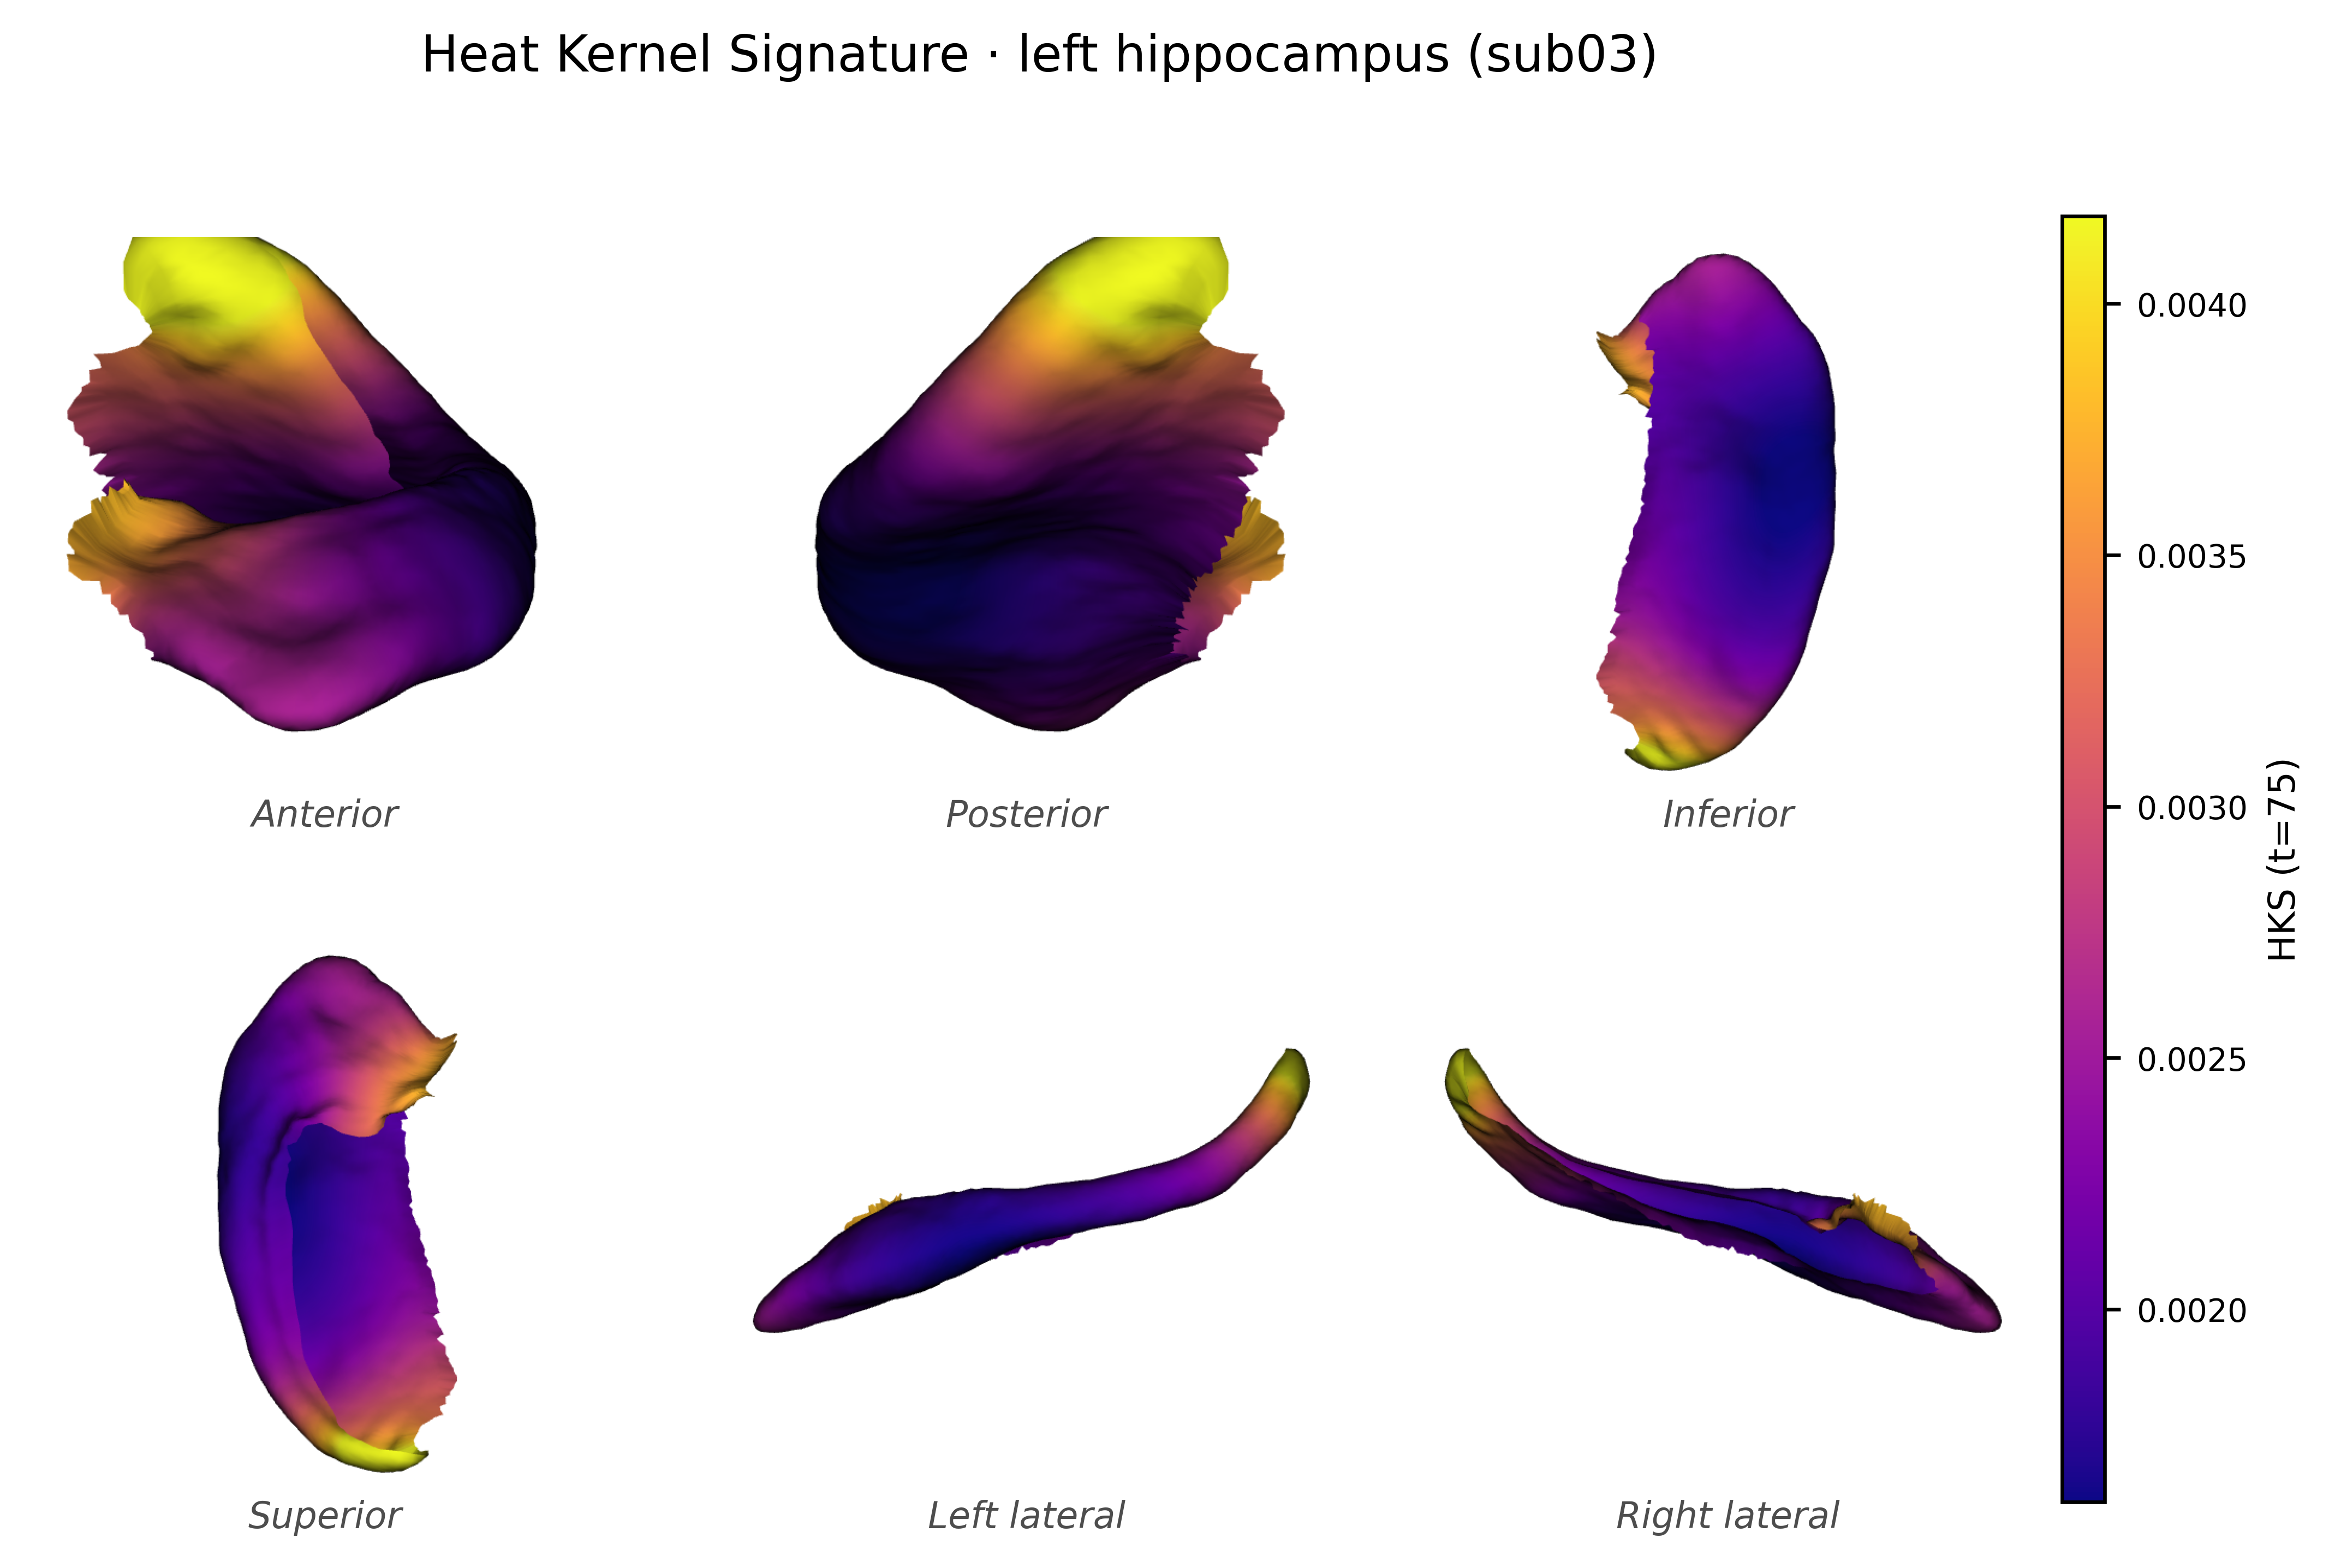

In [4]:
from spectralbrain.viz import plot_surface_sixview
fig = plot_surface_sixview(hipp, scalars=hks3[:, 1], cmap="plasma",
                           scalar_bar_title=f"HKS (t={t3[1]:.2g})",
                           title="Heat Kernel Signature · left hippocampus (sub03)")
plt.show()

## 4. Small-$t$ HKS is a curvature probe

The short-time expansion of the heat kernel gives, to leading order,

$$\mathrm{HKS}(x, t) \;\approx\; \frac{1}{4\pi t}\Big(1 + \tfrac{t}{6}\,S(x) + \cdots\Big),$$

where $S(x)$ is the scalar curvature (twice the Gaussian curvature on a surface).
So at small $t$, HKS should track curvature. We test it: correlate the
smallest-$t$ HKS column with the mesh's own curvature estimate.

Spearman correlation (small-t HKS vs |mean curvature|): rho = 0.355, p = 1.6e-242


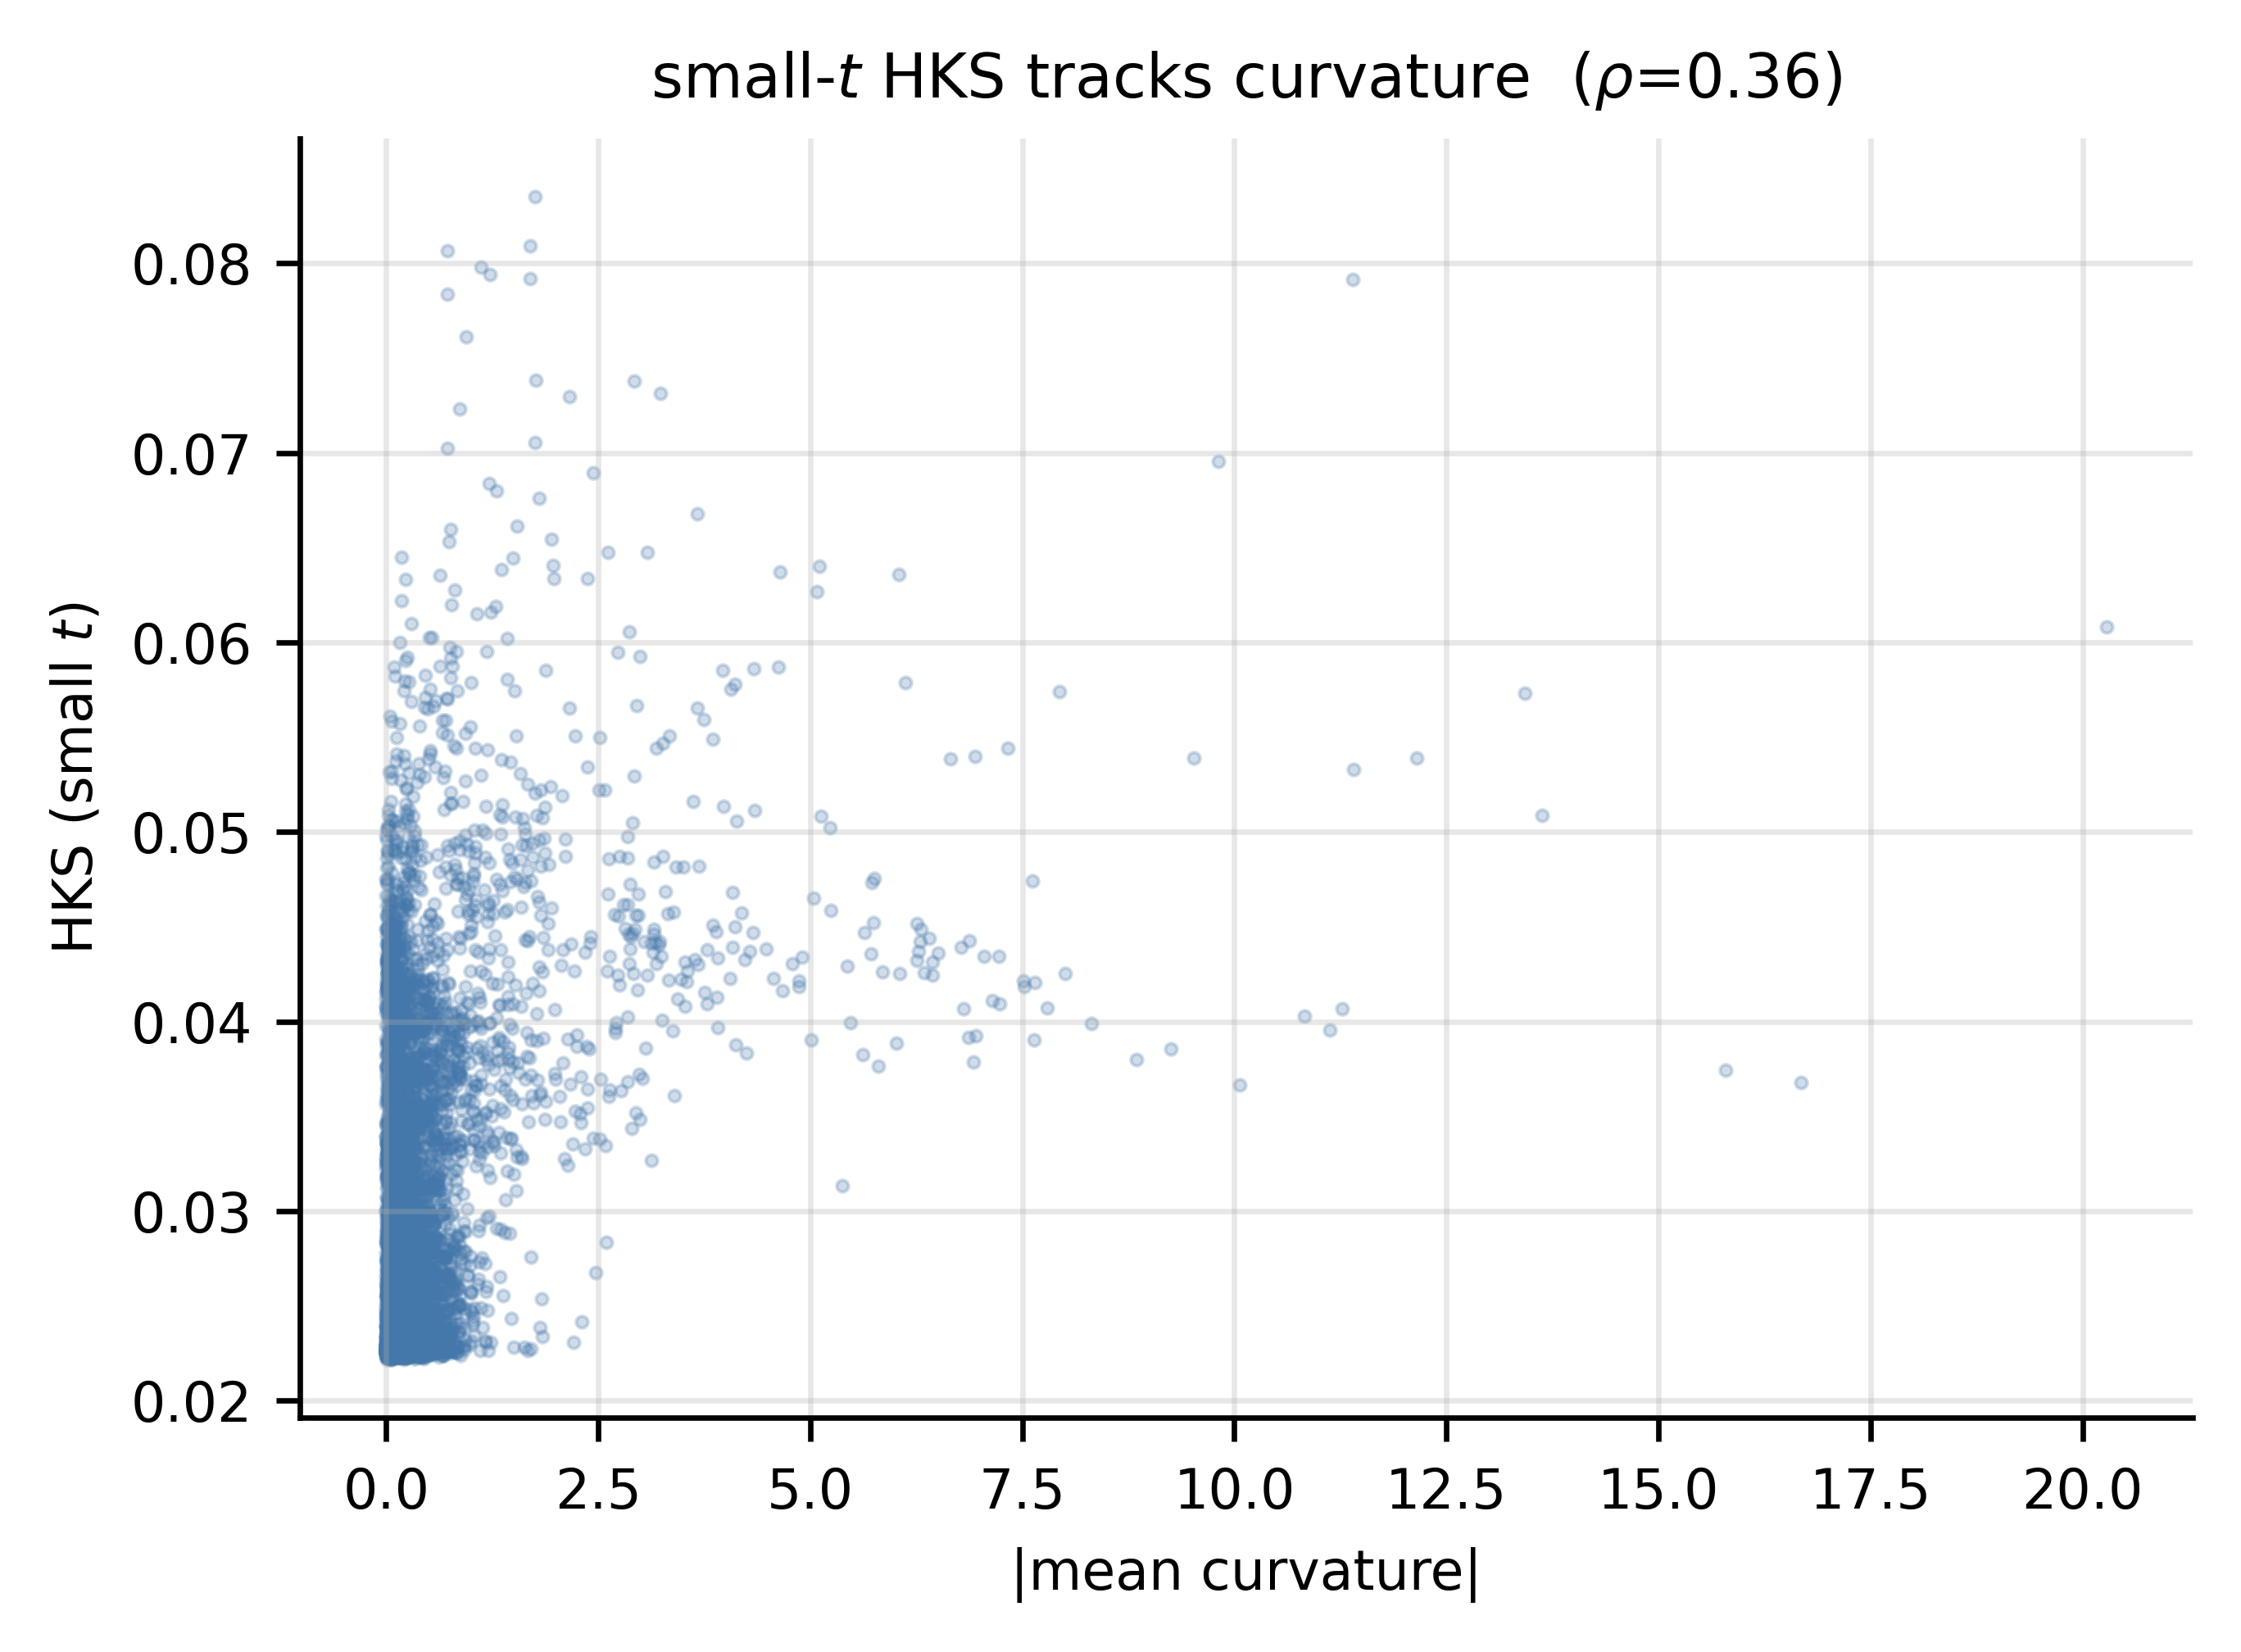

In [5]:
from scipy.stats import spearmanr
kmean = np.abs(hipp.mean_curvature())
rho, p = spearmanr(hks3[:, 0], kmean)
print(f"Spearman correlation (small-t HKS vs |mean curvature|): rho = {rho:.3f}, p = {p:.1e}")

fig, ax = plt.subplots(figsize=(4.6, 3.4))
ax.scatter(kmean, hks3[:, 0], s=3, alpha=0.25)
ax.set_xlabel("|mean curvature|"); ax.set_ylabel("HKS (small $t$)")
ax.set_title(f"small-$t$ HKS tracks curvature  ($\\rho$={rho:.2f})"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. The scale problem, and SI-HKS

HKS has one weakness for cross-subject work: it is **not scale-invariant**.
Scaling a shape by $\alpha$ rescales every eigenvalue by $1/\alpha^2$, which slides
the HKS curve along the $t$-axis. Two hippocampi of identical shape but different
size get different HKS.

The **Scale-Invariant HKS** (Bronstein & Kokkinos 2010) fixes this with a neat
trick: sample HKS on a **logarithmic** time grid (so a scale change becomes a
*shift*), then take the **magnitude of the Fourier transform** along that axis
(which is shift-invariant). `compute_si_hks` does this and returns a few
low-frequency coefficients per vertex.

In [6]:
big = sb.BrainMesh(hipp.vertices * 2.0, hipp.faces)     # same shape, twice the size
dec_big = big.decompose(k=200)

# Plain HKS at fixed t: shifts with scale.
hks_o = np.asarray(sb.compute_hks(dec,     t_values=t3))
hks_b = np.asarray(sb.compute_hks(dec_big, t_values=t3))
print("plain HKS, mean value per scale:")
print(f"  original : {hks_o.mean(0)}")
print(f"  scaled x2: {hks_b.mean(0)}   <- different")

# SI-HKS: stable across scale (vertex order is preserved, so compare per-vertex).
si_o = np.asarray(sb.compute_si_hks(dec))
si_b = np.asarray(sb.compute_si_hks(dec_big))
corr = [np.corrcoef(si_o[:, j], si_b[:, j])[0, 1] for j in range(si_o.shape[1])]
print(f"\nSI-HKS per-frequency correlation (original vs scaled): "
      f"min={min(corr):.3f}, mean={np.mean(corr):.3f}")
print("-> SI-HKS is (nearly) invariant to the 2x rescaling; plain HKS is not.")

[06/09/26 02:00:32] INFO     Laplacian (cotangent): N=8192, nnz=56578

plain HKS, mean value per scale:
  original : [0.02813216 0.00244451 0.00115613]
  scaled x2: [0.02352424 0.00166222 0.00032007]   <- different



SI-HKS per-frequency correlation (original vs scaled): min=1.000, mean=1.000
-> SI-HKS is (nearly) invariant to the 2x rescaling; plain HKS is not.


## Exercises

1. **Scale sweep.** Plot mean HKS vs $t$ for the original and the $2\times$ mesh on
   the same log axes. Confirm the curve shifts horizontally by the predicted
   amount ($\Delta\log t = \log \alpha^2$).
2. **Mode budget.** Recompute HKS with `k=50, 100, 200` modes. At which scale
   ($t$) does the number of modes matter most — small or large $t$? Why?
3. **Curvature, properly.** Replace `mean_curvature` with `gaussian_curvature` in
   section 4. Which curvature does small-$t$ HKS track more tightly, and does the
   short-time expansion explain it?
4. **Subfield contrast.** Render HKS at small $t$ on the hippocampal **tail**
   surface from notebook 2 and compare its curvature structure to the full
   hippocampus.
5. **Descriptor as feature.** Take the full HKS matrix (100 scales) for `sub03_L`
   and `sub04_L`, average over vertices, and measure the Euclidean distance
   between the two mean-HKS curves. How does it compare to their ShapeDNA distance
   from notebook 3?


## What's next

HKS is a **low-pass** descriptor: heat diffusion smooths away high frequencies.
**Notebook 05** introduces the **Wave Kernel Signature**, which uses the
Schrödinger equation to build a **band-pass** descriptor with sharper frequency
localisation, plus the **Global Point Signature** embedding. Together they round
out the per-vertex descriptor toolkit before we turn to correspondence and
statistics.
